In [12]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

torch.__version__

'2.10.0'

In [13]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

# Parameter definitions can be gotten from https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST

In [14]:
# We unpack the tuple to inspect the data
# The pixels stand for the numeric (tensor) representation of the clothing item
pixels, category = train_data[0]
pixels

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [15]:
# 9 is the category of above image, could be a shoe, who knows
category

9

In [16]:
pixels.shape

torch.Size([1, 28, 28])

The shape suggests that the height of the image is 28 pixels, the width is also 28 pixels, and the color channels 1.
[color_channels = 1, height = 28, width = 28]
Color channels is kind of like the color that the image has, be it a greyscale image, or colored image with 3 as it's color scale representing RGB

In [17]:
# Now we check how many samples exist
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

We have 60,000 training samples and 10,000 testing samples

In [18]:
# Now we check the names of the targets using .classes
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Since train_data.classes is a list, we can see what clothing types are in the first 10 images.
Just for fun

In [19]:
for i in range(10):
    pixels, category = train_data[i]
    print(train_data.classes[category])

Ankle boot
T-shirt/top
T-shirt/top
Dress
T-shirt/top
Pullover
Sneaker
Pullover
Sandal
Sandal


Clothing Shape {torch.Size([1, 28, 28])}


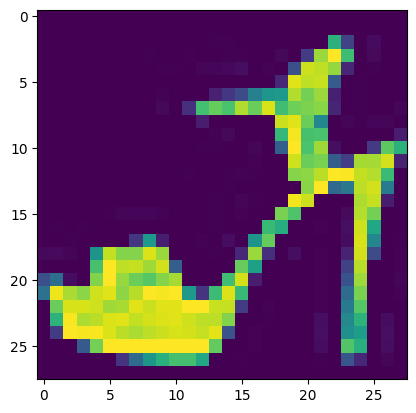

In [20]:
# Visualize
print(f"Clothing Shape",{pixels.shape})
plt.imshow(pixels.squeeze())

Looks like the first item is actually a type of shoe.
matplotlib will take in a 2d shape to make a plot, but as our tensor is 3d([1, 28, 28]), we use .squeeze
This basically removes an dimension that has a size of exactly 1, and that would remove our greyscale color, thus why we're having this neon one.

Clothing Shape {torch.Size([1, 28, 28])}


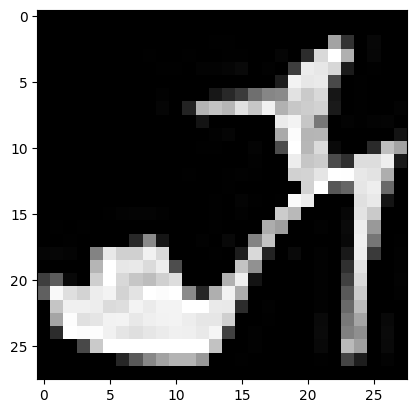

In [10]:
# Visualize again
print(f"Clothing Shape",{pixels.shape})
plt.imshow(pixels.squeeze(), cmap='grey')

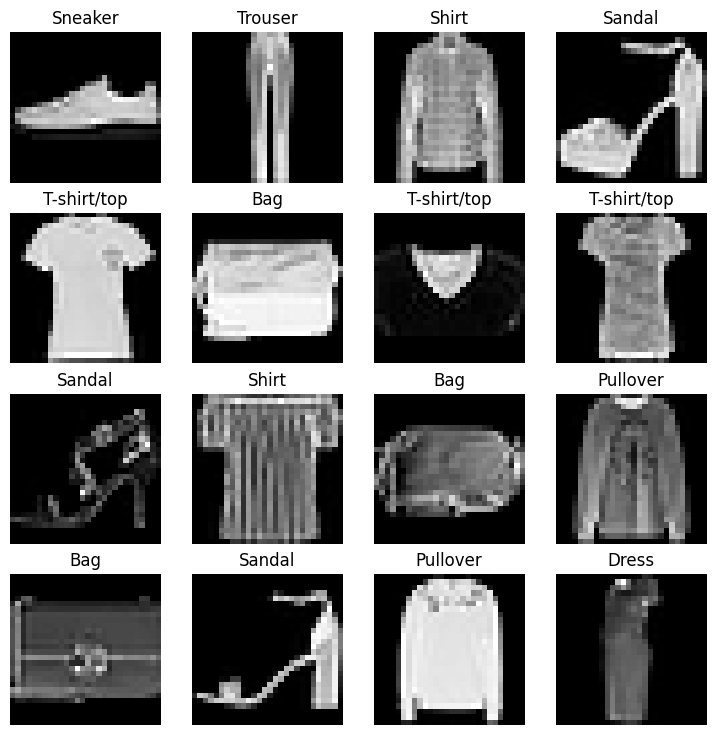

In [42]:
# Plot more images
# torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows, cols = 4,4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

In [28]:
train_data[4]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.1020, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.7412, 0.8078, 0.7333, 0.1255, 0.0000, 0.0000, 0.0000, 0.1020,
           0.8510, 0.8863, 0.7686, 0.0431, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.7529, 0.8902, 0.9176, 0.9529, 0.9020, 0.5765, 0.9373, 0.9490,
           0.9176, 0.8549, 0.8196, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.6784, 0.8824, 0.8431, 0.9137, 0.9961, 0.0000, 0.7608, 0.9412,
           0.8510, 0.8667, 0.7451, 0.0000, 

In [48]:
# Setting up a dataloader to pass the data into the model
from torch.utils.data import DataLoader


# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Transform the dataset into batches
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [50]:
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader {len(test_dataloader)} batches of {BATCH_SIZE}")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x118bebb10>, <torch.utils.data.dataloader.DataLoader object at 0x118beb890>)
Length of train dataloader 1875 batches of 32
Length of test dataloader 313 batches of 32


In [52]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 9, label size: torch.Size([])


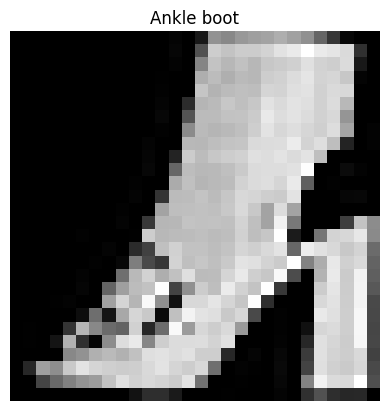

In [53]:
# Show a sample
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")